***EMPLOYEE ATTRITION DATASET ANALYSIS***

--Importing the necessary libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df=pd.read_csv(r"C:\Users\B KIRANA\Downloads\Project_emp_attrition_dataset.csv")

In [43]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [44]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [46]:
df.shape

(1470, 35)

In [47]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

***There is no null values in the employee attrition dataset***

In [48]:
df["EmployeeCount"].nunique()

1

In [49]:
df["EmployeeNumber"].nunique()

1470

In [50]:
df["StandardHours"].nunique()

1

In [51]:
df["Over18"].nunique()

1

--The above fields either have values that are equal to the row count or hold only one unique value which does'nt add value to our analysis so it is okay to drop those columns

In [52]:
df.drop(["EmployeeCount","EmployeeNumber","StandardHours","Over18"],axis=1,inplace=True)

In [53]:
df.shape

(1470, 31)

In [54]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

***OUTLIER DETECTION***

{'whiskers': [<matplotlib.lines.Line2D at 0x18fbb0a5550>,
 'caps': [<matplotlib.lines.Line2D at 0x18fbb0a6810>,
 'boxes': [<matplotlib.lines.Line2D at 0x18fbb0a4c50>],
 'medians': [<matplotlib.lines.Line2D at 0x18fbb0a7810>],
 'fliers': [<matplotlib.lines.Line2D at 0x18fbb0b8050>],
 'means': []}

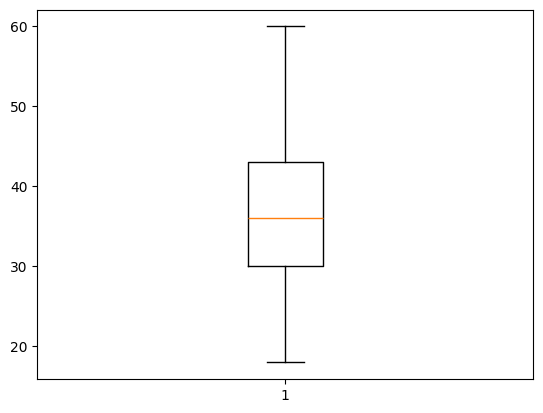

In [55]:
plt.boxplot(df["Age"])

{'whiskers': [<matplotlib.lines.Line2D at 0x18fbb104f90>,
 'caps': [<matplotlib.lines.Line2D at 0x18fbb106250>,
 'boxes': [<matplotlib.lines.Line2D at 0x18fbb104690>],
 'medians': [<matplotlib.lines.Line2D at 0x18fbb107450>],
 'fliers': [<matplotlib.lines.Line2D at 0x18fbb107c10>],
 'means': []}

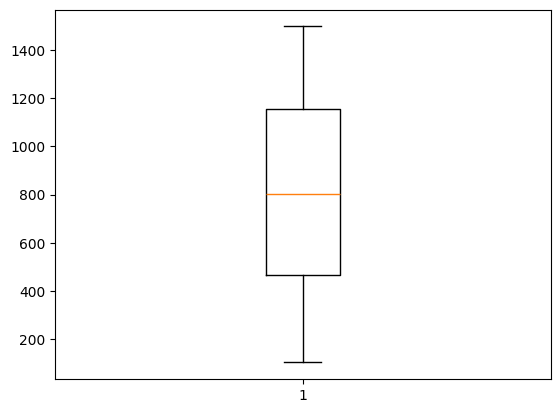

In [56]:
plt.boxplot(df["DailyRate"])

{'whiskers': [<matplotlib.lines.Line2D at 0x18fbb153cd0>,
 'caps': [<matplotlib.lines.Line2D at 0x18fbb15d050>,
 'boxes': [<matplotlib.lines.Line2D at 0x18fbb1533d0>],
 'medians': [<matplotlib.lines.Line2D at 0x18fbb15e210>],
 'fliers': [<matplotlib.lines.Line2D at 0x18fbb15ea50>],
 'means': []}

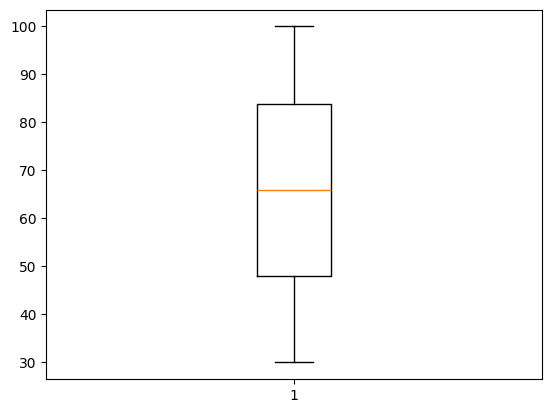

In [57]:
plt.boxplot(df["HourlyRate"])

{'whiskers': [<matplotlib.lines.Line2D at 0x18fbb1c8590>,
 'caps': [<matplotlib.lines.Line2D at 0x18fbb1c98d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x18fbb1c3d90>],
 'medians': [<matplotlib.lines.Line2D at 0x18fbb1ca990>],
 'fliers': [<matplotlib.lines.Line2D at 0x18fbb1cb190>],
 'means': []}

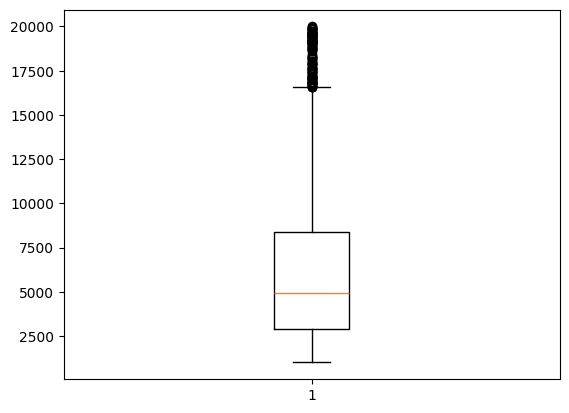

In [58]:
plt.boxplot(df["MonthlyIncome"])    #high income cannot be considered as outliers ,if removed can lead to loss of data

{'whiskers': [<matplotlib.lines.Line2D at 0x18fbb2344d0>,
 'caps': [<matplotlib.lines.Line2D at 0x18fbb235790>,
 'boxes': [<matplotlib.lines.Line2D at 0x18fbb22bb10>],
 'medians': [<matplotlib.lines.Line2D at 0x18fbb236750>],
 'fliers': [<matplotlib.lines.Line2D at 0x18fbb236f50>],
 'means': []}

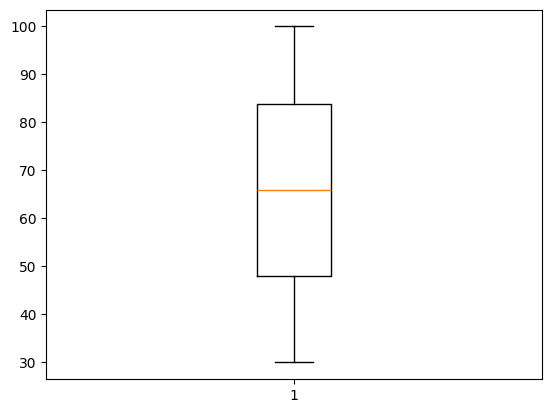

In [59]:
plt.boxplot(df["HourlyRate"])

{'whiskers': [<matplotlib.lines.Line2D at 0x18fbb3e0ad0>,
 'caps': [<matplotlib.lines.Line2D at 0x18fbb3e1a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x18fbb3e02d0>],
 'medians': [<matplotlib.lines.Line2D at 0x18fbb3e2a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x18fbb3e3290>],
 'means': []}

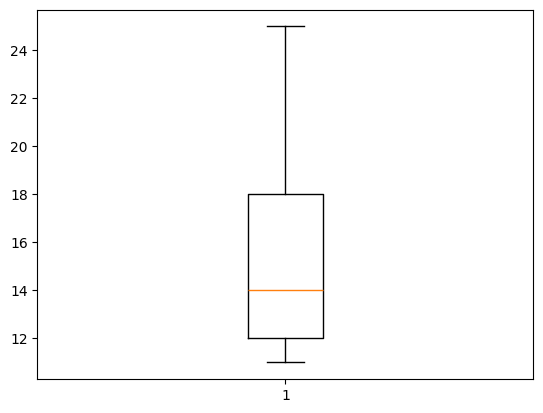

In [60]:
plt.boxplot(df["PercentSalaryHike"])

In [61]:
df["Department"].nunique()

3

In [62]:
df["EducationField"].nunique()

6

In [63]:
df["Gender"].nunique()

2

In [64]:
df["MaritalStatus"].nunique()

3

Most fields prefer to be the rating got from the employees

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [68]:
df.to_csv("employee_cleaned")